# Pyro-P1: PyroNear Solo — Vanilla YOLO11-S Baseline

**Goal.** Establish the PyroNear-solo vanilla anchor for the ICONIP ablation chain.
One training run, vanilla YOLO11-S (cold start from `yolo11s.pt`), pyro-sdis dataset
with `nc=1` (smoke only — PyroNear has no fire class).

**Reference points.**
- Published unified-corpus (D-Fire + NEMO + PyroNear) numbers:
  - Vanilla YOLO11-S unified: **recall = 88.52%, FP = 60.74%**
  - DCT + AG unified (best): recall = 92.05%, FP = 58.49%
- Lostanlen et al. literature (different test split, contextual only):
  - Single-frame YOLOv8: F1 = 0.683
  - Combined-dataset YOLOv8: F1 = 0.789

**Primary metric.** Image-level binary alert (a frame is flagged positive if
*any* detection exceeds τ). Box-level mAP@0.5 is reported as secondary.

**Hardware.** Kaggle T4 (16 GB). Wall-time budget: < 10 h.


## 1. Setup

In [1]:
!pip install ultralytics pycocotools matplotlib opencv-python-headless -q

import os, gc, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ultralytics import YOLO

print(f"PyTorch         : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM (GB)       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch         : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM (GB)       : 15.6


---

## 2. Dataset (pyro-sdis, pre-prepared)


In [2]:
# Dataset is ALREADY prepared at this path — no copying / filtering here.
# Pipeline differs from D-Fire (Phase 1): do NOT reuse D-Fire data loading.
PYRO_PATH = "/kaggle/working/pyro_yolo"

print("=" * 64)
print("PyroNear (pyro-sdis) — Pre-computed Dataset Statistics")
print("=" * 64)
print(f"  Path                  : {PYRO_PATH}")
print(f"  Total train boxes     : 28,167")
print(f"  Hard negatives train  : 4,745 images (empty label files)")
print(f"  Mean bbox edge (px)   : 31.8   (at 640×640 input)")
print(f"  Median bbox edge (px) : 24.0")
print(f"  % COCO small (<32px)  : 69.4%")
print(f"  % COCO medium         : 28.5%")
print(f"  % COCO large          : 2.2%")
print()
print("  NOTE: PyroNear has 1 class (smoke). NO fire class. nc=1.")
print("=" * 64)


PyroNear (pyro-sdis) — Pre-computed Dataset Statistics
  Path                  : /kaggle/working/pyro_yolo
  Total train boxes     : 28,167
  Hard negatives train  : 4,745 images (empty label files)
  Mean bbox edge (px)   : 31.8   (at 640×640 input)
  Median bbox edge (px) : 24.0
  % COCO small (<32px)  : 69.4%
  % COCO medium         : 28.5%
  % COCO large          : 2.2%

  NOTE: PyroNear has 1 class (smoke). NO fire class. nc=1.


---

In [3]:
yaml_content = """# pyro-sdis Solo — Pyro-P1 (Vanilla YOLO11-S baseline)
path: /kaggle/working/pyro_yolo
train: images/train
val: images/val
nc: 1
names:
  0: smoke
"""

yaml_path = "/kaggle/working/pyro_solo.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"data.yaml written → {yaml_path}")
print("─" * 64)
print(yaml_content)


data.yaml written → /kaggle/working/pyro_solo.yaml
────────────────────────────────────────────────────────────────
# pyro-sdis Solo — Pyro-P1 (Vanilla YOLO11-S baseline)
path: /kaggle/working/pyro_yolo
train: images/train
val: images/val
nc: 1
names:
  0: smoke



In [4]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient
import os
os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")

Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


---

In [5]:
import os
from pathlib import Path
# Assuming you are using the HF datasets library. If not, define 'ds' however you loaded it.
# from datasets import load_dataset
# ds = load_dataset("your-dataset-name") 

PYRO_PATH = "/kaggle/working/pyro_yolo"

PYRO_DIRS = {
    "train_imgs": f"{PYRO_PATH}/images/train",
    "val_imgs":   f"{PYRO_PATH}/images/val",
    "train_lbls": f"{PYRO_PATH}/labels/train",
    "val_lbls":   f"{PYRO_PATH}/labels/val",
}

# 1. Create Directories
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)

# 2. Conversion Function
def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")

# 3. Execute Conversion
print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")


# 4. Integrity Check
print("── Dataset Integrity Check ────────────────────────────────────────────")

img_train = sorted(Path(f"{PYRO_PATH}/images/train").glob("*.*"))
img_val   = sorted(Path(f"{PYRO_PATH}/images/val").glob("*.*"))
lbl_train = sorted(Path(f"{PYRO_PATH}/labels/train").glob("*.txt"))
lbl_val   = sorted(Path(f"{PYRO_PATH}/labels/val").glob("*.txt"))

print(f"  Train images : {len(img_train):>6,}   (expected ≈ 24,792)")
print(f"  Train labels : {len(lbl_train):>6,}   (expected ≈ 29,537)")
print(f"  Val   images : {len(img_val):>6,}   (expected   4,099)")
print(f"  Val   labels : {len(lbl_val):>6,}   (expected   4,099)")

# ── Hard-negative count in val (empty label files = 0 bytes or 0 non-empty lines)
def is_empty_label(p: Path) -> bool:
    if p.stat().st_size == 0:
        return True
    return p.read_text().strip() == ""

hard_neg_val   = [p for p in lbl_val   if is_empty_label(p)]
hard_neg_train = [p for p in lbl_train if is_empty_label(p)]
n_hard_neg_val = len(hard_neg_val)
n_positive_val = len(img_val) - n_hard_neg_val

print(f"\n  Hard negatives (val)   : {n_hard_neg_val:>6,}   ← FP-rate denominator")
print(f"  Positive images (val)  : {n_positive_val:>6,}   ← Recall denominator")
print(f"  Hard negatives (train) : {len(hard_neg_train):>6,}   (expected ≈ 4,745)")

# ── Train box count sanity check
total_train_boxes = 0
for p in lbl_train:
    if p.stat().st_size > 0:
        with open(p) as f:
            total_train_boxes += sum(1 for line in f if line.strip())
print(f"  Total train boxes (counted) : {total_train_boxes:>6,}   (expected ≈ 28,167)")

# ── Class-id check: all labels must be class 0 (smoke). Catch any nc=2 leftovers.
bad_class_files = []
for p in lbl_train[:2000]:                  # sample 2k for speed
    if p.stat().st_size == 0:
        continue
    for line in p.read_text().splitlines():
        if line.strip() and line.split()[0] != "0":
            bad_class_files.append(p.name)
            break
print(f"  Sample class-id check  : {len(bad_class_files)} files with non-zero class "
      f"(out of 2,000 sampled) — must be 0")
assert len(bad_class_files) == 0, f"Found non-smoke labels: {bad_class_files[:5]}"

print("\n  ✅ Dataset integrity OK")

Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images
── Dataset Integrity Check ────────────────────────────────────────────
  Train images : 29,537   (expected ≈ 24,792)
  Train labels : 29,537   (expected ≈ 29,537)
  Val   images :  4,099   (expected   4,099)
  Val   labels :  4,099   (expected   4,099)

  Hard negatives (val)   :    754   ← FP-rate denominator
  Positive images (val)  :  3,345   ← Recall denominator
  Hard negatives (train) :  4,745   (expected ≈ 4,745)
  Total train boxes (counted) : 28,167   (expected ≈ 28,167)
  Sample class-id check  : 0 files with non-zero class (out of 2,000 sampled) — must be 0

  ✅ Dataset integrity OK


---

## 3. Architecture — Vanilla YOLO11-S sanity check


In [6]:
print("=" * 64)
print("VANILLA YOLO11-S ARCHITECTURE CHECK")
print("=" * 64)

sanity = YOLO("yolo11s.pt")
layers = list(sanity.model.model)

print(f"\nTotal layers  : {len(layers)}   (expected 24 for YOLO11-S)")
print(f"Last layer    : {type(layers[-1]).__name__}   (expected Detect)")

# Layer table
print("\nLayer summary:")
print(f"  {'Idx':>4}  {'Type':<28}")
print(f"  {'-'*35}")
for i, layer in enumerate(layers):
    print(f"  [{i:>2d}]  {type(layer).__name__}")

# Param count (snapshot for results JSON)
params_total = sum(p.numel() for p in sanity.model.parameters())
params_M     = params_total / 1e6
print(f"\nTotal parameters : {params_total:>12,}  ({params_M:.2f} M)")

# Forward pass — nc=80 pretrained head; becomes nc=1 at train start
print("\nForward pass check (batch=1, 640×640, pretrained nc=80):")
sanity.model.eval()
dummy = torch.zeros(1, 3, 640, 640)
with torch.no_grad():
    out = sanity.model(dummy)
preds = out[0] if isinstance(out, (list, tuple)) else out
print(f"  Output shape : {tuple(preds.shape)}")
print(f"  Expected     : (1, 84, 8400)   [nc=80 pretrained]")
assert preds.shape == (1, 84, 8400), f"Unexpected shape: {preds.shape}"

print()
print("=" * 64)
print("ALL CHECKS PASSED ✅")
print("  No custom modules present — pure vanilla YOLO11-S")
print("  Detect head will be re-initialised for nc=1 at training start")
print("=" * 64)

del sanity
gc.collect()
torch.cuda.empty_cache()


VANILLA YOLO11-S ARCHITECTURE CHECK

Total layers  : 24   (expected 24 for YOLO11-S)
Last layer    : Detect   (expected Detect)

Layer summary:
   Idx  Type                        
  -----------------------------------
  [ 0]  Conv
  [ 1]  Conv
  [ 2]  C3k2
  [ 3]  Conv
  [ 4]  C3k2
  [ 5]  Conv
  [ 6]  C3k2
  [ 7]  Conv
  [ 8]  C3k2
  [ 9]  SPPF
  [10]  C2PSA
  [11]  Upsample
  [12]  Concat
  [13]  C3k2
  [14]  Upsample
  [15]  Concat
  [16]  C3k2
  [17]  Conv
  [18]  Concat
  [19]  C3k2
  [20]  Conv
  [21]  Concat
  [22]  C3k2
  [23]  Detect

Total parameters :    9,458,752  (9.46 M)

Forward pass check (batch=1, 640×640, pretrained nc=80):
  Output shape : (1, 84, 8400)
  Expected     : (1, 84, 8400)   [nc=80 pretrained]

ALL CHECKS PASSED ✅
  No custom modules present — pure vanilla YOLO11-S
  Detect head will be re-initialised for nc=1 at training start


---

## 4. Training — 50 epochs, batch=16, imgsz=640, cls_pw=0.0


In [7]:
model = YOLO("yolo11s.pt")

train_start = time.time()
results = model.train(
    data      = "/kaggle/working/pyro_solo.yaml",
    epochs    = 50,
    imgsz     = 640,
    batch     = 16,
    device    = 0,
    project   = "/kaggle/working/runs",
    name      = "yolo11s_pyro_p1_vanilla",
    patience  = 15,
    optimizer = "auto",
    lr0       = 0.01,
    lrf       = 0.01,
    cls_pw    = 0.0,          # YOLO11 default — DO NOT change
    seed      = 0,
    save      = True,
    plots     = True,
    val       = True,
    workers   = 2,
    exist_ok  = True,
)
train_seconds = time.time() - train_start

RUN_DIR = "/kaggle/working/runs/yolo11s_pyro_p1_vanilla"
BEST_PT = f"{RUN_DIR}/weights/best.pt"
print(f"\nTraining complete ✅")
print(f"  Wall time     : {train_seconds/3600:.2f} h   (budget 10 h)")
print(f"  Best weights  → {BEST_PT}")


Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pyro_solo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_pyro_p1_vanilla, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

---

── Per-epoch val metrics ──────────────────────────────────────────────
 epoch  train/box_loss  val/box_loss  train/cls_loss  val/cls_loss  metrics/mAP50(B)  metrics/precision(B)  metrics/recall(B)
     1         1.74531       1.65380         2.19407       3.54762           0.52373               0.55002            0.54820
     2         1.78159       1.82351         1.47184       2.70839           0.51281               0.56191            0.55885
     3         1.85608       1.83538         1.52867       2.95031           0.47364               0.52731            0.50178
     4         1.79994       1.75061         1.46174       2.31615           0.54185               0.58908            0.55751
     5         1.68092       1.56012         1.34000       2.60300           0.58164               0.59691            0.61195
     6         1.59988       1.48993         1.25338       2.43645           0.62068               0.61533            0.62557
     7         1.55610       1.44383         1

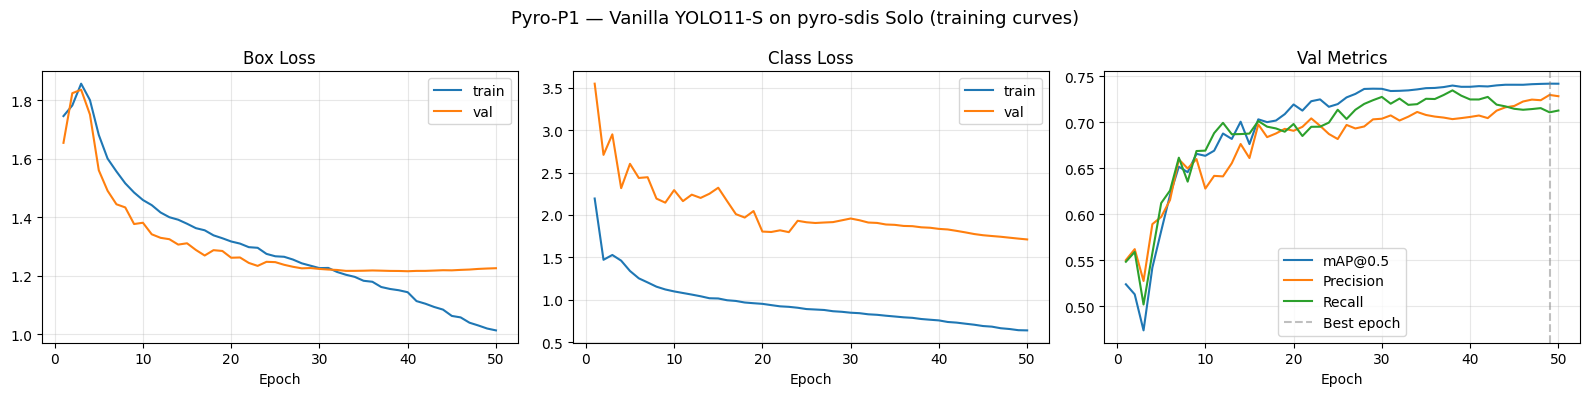

Training curves saved → /kaggle/working/pyro_p1_training_curves.png ✅


In [8]:
RUN_DIR = "/kaggle/working/runs/yolo11s_pyro_p1_vanilla"

df = pd.read_csv(f"{RUN_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch val metrics ──────────────────────────────────────────────")
cols_to_show = [c for c in [
    "epoch",
    "train/box_loss", "val/box_loss",
    "train/cls_loss", "val/cls_loss",
    "metrics/mAP50(B)",
    "metrics/precision(B)",
    "metrics/recall(B)",
] if c in df.columns]
print(df[cols_to_show].to_string(index=False))

best_epoch    = int(df["metrics/mAP50(B)"].idxmax())
epochs_actual = int(df["epoch"].max())
print(f"\nBest val mAP@0.5 : {df.loc[best_epoch, 'metrics/mAP50(B)']:.4f}  "
      f"at epoch {int(df.loc[best_epoch, 'epoch'])}")
print(f"Epochs actually trained : {epochs_actual}   (target 50; early-stop if patience triggered)")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Pyro-P1 — Vanilla YOLO11-S on pyro-sdis Solo (training curves)",
             fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].grid(alpha=0.3)

if "train/cls_loss" in df.columns:
    axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
    axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].axvline(x=int(df.loc[best_epoch, "epoch"]), color="gray",
                linestyle="--", alpha=0.5, label="Best epoch")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/pyro_p1_training_curves.png", dpi=120)
plt.show()
print("Training curves saved → /kaggle/working/pyro_p1_training_curves.png ✅")


---

## 5. Evaluation


In [9]:
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

RUN_DIR    = "/kaggle/working/runs/yolo11s_pyro_p1_vanilla"
BEST_PT    = f"{RUN_DIR}/weights/best.pt"
eval_model = YOLO(BEST_PT)
print(f"Loaded best checkpoint: {BEST_PT}")


VRAM free: 15.4 GB ✅
Loaded best checkpoint: /kaggle/working/runs/yolo11s_pyro_p1_vanilla/weights/best.pt


In [10]:
# ════════════════════════════════════════════════════════════════
# BOX-LEVEL EVAL — pyro-sdis val split (secondary metric)
# ════════════════════════════════════════════════════════════════
print("── Box-level Evaluation: pyro-sdis VAL split ─────────────────────────")

metrics_val = eval_model.val(
    data     = "/kaggle/working/pyro_solo.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    plots    = True,
    project  = RUN_DIR,
    name     = "eval_val",
    exist_ok = True,
)

map50_val   = float(metrics_val.box.map50)
map5095_val = float(metrics_val.box.map)
prec_val    = float(metrics_val.box.mp)
rec_val     = float(metrics_val.box.mr)
f1_box      = 2 * prec_val * rec_val / max(prec_val + rec_val, 1e-8)

print(f"\n  mAP@0.5      : {map50_val:.4f}   ({map50_val*100:.2f}%)")
print(f"  mAP@0.5:0.95 : {map5095_val:.4f}   ({map5095_val*100:.2f}%)")
print(f"  Precision    : {prec_val:.4f}")
print(f"  Recall (box) : {rec_val:.4f}")
print(f"  F1 (box)     : {f1_box:.4f}")


── Box-level Evaluation: pyro-sdis VAL split ─────────────────────────
Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1727.0±539.9 MB/s, size: 73.4 KB)
val: Scanning /kaggle/working/pyro_yolo/labels/val.cache... 4099 images, 754 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4099/4099 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 257/257 7.4it/s 34.7s
                   all       4099       3942      0.725      0.713      0.742      0.476
Speed: 0.5ms preprocess, 5.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/yolo11s_pyro_p1_vanilla/eval_val

  mAP@0.5      : 0.7418   (74.18%)
  mAP@0.5:0.95 : 0.4761   (47.61%)
  Precision    : 0.7246
  Recall (box) : 0.7133
  F1 (box)     : 0.7189


In [11]:
# ════════════════════════════════════════════════════════════════
# IMAGE-LEVEL EVAL — predict once at low conf, derive every τ
# ════════════════════════════════════════════════════════════════
# Why predict once: the max-confidence detection on each image is
# invariant to τ for any τ ≤ predict-time-conf. So one pass at
# conf=0.001 lets us evaluate every threshold analytically.
print("── Image-level Evaluation: pyro-sdis VAL split ───────────────────────")

val_img_dir = Path(f"{PYRO_PATH}/images/val")
val_lbl_dir = Path(f"{PYRO_PATH}/labels/val")
val_imgs    = sorted(val_img_dir.glob("*.*"))

# ── Classify each val image as positive (has ≥1 GT box) or hard-negative
def is_hard_neg(stem: str) -> bool:
    lbl = val_lbl_dir / f"{stem}.txt"
    if not lbl.exists() or lbl.stat().st_size == 0:
        return True
    return lbl.read_text().strip() == ""

img_is_pos = {p.name: (not is_hard_neg(p.stem)) for p in val_imgs}
n_total    = len(val_imgs)
n_positive = sum(img_is_pos.values())
n_hardneg  = n_total - n_positive

print(f"  Total val images   : {n_total:>6,}")
print(f"  Positive images    : {n_positive:>6,}   (recall denominator)")
print(f"  Hard-negative imgs : {n_hardneg:>6,}   (FP-rate denominator)")

# ── Single low-conf prediction pass; store max conf per image
print(f"\n  Running predictions at conf=0.001 (single pass)...")
BATCH_SIZE = 200
max_conf_per_img = {}

for i in range(0, len(val_imgs), BATCH_SIZE):
    chunk = [str(p) for p in val_imgs[i:i + BATCH_SIZE]]
    preds = eval_model.predict(
        source  = chunk,
        imgsz   = 640,
        conf    = 0.001,
        device  = 0,
        verbose = False,
    )
    for path_str, r in zip(chunk, preds):
        name = Path(path_str).name
        if r.boxes is not None and len(r.boxes) > 0:
            max_conf_per_img[name] = float(r.boxes.conf.max().item())
        else:
            max_conf_per_img[name] = 0.0
    torch.cuda.empty_cache()
    if (i // BATCH_SIZE + 1) % 5 == 0:
        done = min(i + BATCH_SIZE, len(val_imgs))
        print(f"    Processed {done}/{len(val_imgs)} ...")

assert len(max_conf_per_img) == n_total, \
    f"Prediction count mismatch: {len(max_conf_per_img)} vs {n_total}"
print(f"  ✅ Prediction pass complete ({len(max_conf_per_img)} images)")


── Image-level Evaluation: pyro-sdis VAL split ───────────────────────
  Total val images   :  4,099
  Positive images    :  3,345   (recall denominator)
  Hard-negative imgs :    754   (FP-rate denominator)

  Running predictions at conf=0.001 (single pass)...
    Processed 1000/4099 ...
    Processed 2000/4099 ...
    Processed 3000/4099 ...
    Processed 4000/4099 ...
  ✅ Prediction pass complete (4099 images)


In [12]:
# ── Helper: image-level metrics at a given τ ──────────────────────────────
def metrics_at_tau(tau: float):
    tp = fp = fn = tn = 0
    for name, conf in max_conf_per_img.items():
        flagged = conf >= tau
        if img_is_pos[name]:
            if flagged: tp += 1
            else:       fn += 1
        else:
            if flagged: fp += 1
            else:       tn += 1
    n_pos = tp + fn
    n_neg = fp + tn
    recall  = tp / max(n_pos, 1)
    fp_rate = fp / max(n_neg, 1)
    prec    = tp / max(tp + fp, 1)
    f1      = 2 * prec * recall / max(prec + recall, 1e-8)
    return {"tau": tau, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "recall": recall, "fp_rate": fp_rate,
            "precision": prec, "f1": f1}

# ── Required discrete sweep ───────────────────────────────────────────────────
print("── Confidence Threshold Sweep (image-level) ──────────────────────────")
sweep_taus = [0.10, 0.15, 0.25, 0.35, 0.50]
sweep_rows = [metrics_at_tau(t) for t in sweep_taus]

print(f"\n  {'τ':>6} {'Recall':>10} {'FP rate':>10} {'Precision':>12} {'F1':>8}")
print(f"  {'-'*50}")
for r in sweep_rows:
    print(f"  {r['tau']:>6.2f} {r['recall']*100:>9.2f}% {r['fp_rate']*100:>9.2f}% "
          f"{r['precision']*100:>11.2f}% {r['f1']*100:>7.2f}%")

# ── Operating point @ τ=0.25 ──────────────────────────────────────────────────
row_025 = next(r for r in sweep_rows if abs(r["tau"] - 0.25) < 1e-6)
img_recall_025  = row_025["recall"]
img_fp_rate_025 = row_025["fp_rate"]
img_prec_025    = row_025["precision"]
f1_025          = row_025["f1"]

print(f"\n── Primary Operating Point (τ=0.25) ──────────────────────────────────")
print(f"  TP / FP / FN / TN   : {row_025['tp']} / {row_025['fp']} / "
      f"{row_025['fn']} / {row_025['tn']}")
print(f"  Image-level Recall  : {img_recall_025*100:.2f}%")
print(f"  Image-level FP rate : {img_fp_rate_025*100:.2f}%")
print(f"  Image-level Prec    : {img_prec_025*100:.2f}%")
print(f"  Image-level F1      : {f1_025*100:.2f}%")

# ── Fine-grained τ search for optimal F1 ──────────────────────────────────────
print("\n── Optimal F1 Search (τ ∈ [0.01, 0.99], step 0.01) ───────────────────")
fine_taus = np.arange(0.01, 1.00, 0.01)
fine_rows = [metrics_at_tau(float(t)) for t in fine_taus]
best        = max(fine_rows, key=lambda r: r["f1"])
tau_optimal = float(best["tau"])
f1_optimal  = float(best["f1"])

print(f"  Optimal τ*    : {tau_optimal:.3f}")
print(f"  Recall        : {best['recall']*100:.2f}%")
print(f"  FP rate       : {best['fp_rate']*100:.2f}%")
print(f"  Precision     : {best['precision']*100:.2f}%")
print(f"  F1 (image)    : {f1_optimal*100:.2f}%")


── Confidence Threshold Sweep (image-level) ──────────────────────────

       τ     Recall    FP rate    Precision       F1
  --------------------------------------------------
    0.10     94.17%     69.23%       85.78%   89.78%
    0.15     92.59%     62.86%       86.73%   89.56%
    0.25     88.70%     52.79%       88.17%   88.44%
    0.35     82.75%     42.57%       89.61%   86.04%
    0.50     69.27%     28.25%       91.58%   78.88%

── Primary Operating Point (τ=0.25) ──────────────────────────────────
  TP / FP / FN / TN   : 2967 / 398 / 378 / 356
  Image-level Recall  : 88.70%
  Image-level FP rate : 52.79%
  Image-level Prec    : 88.17%
  Image-level F1      : 88.44%

── Optimal F1 Search (τ ∈ [0.01, 0.99], step 0.01) ───────────────────
  Optimal τ*    : 0.010
  Recall        : 98.48%
  FP rate       : 85.94%
  Precision     : 83.56%
  F1 (image)    : 90.41%


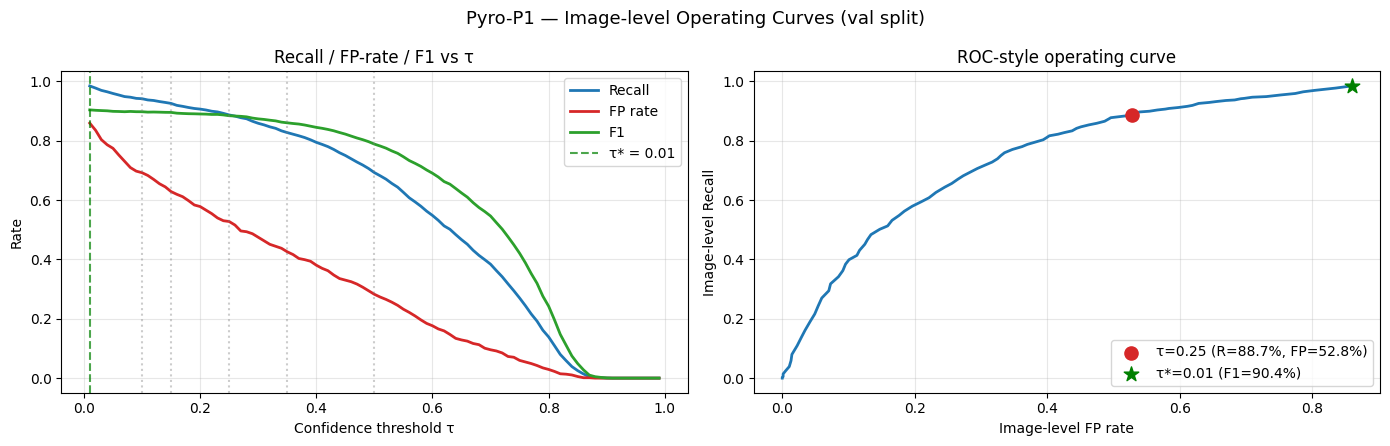

Threshold-sweep plot saved → /kaggle/working/pyro_p1_threshold_sweep.png ✅


In [13]:
# ── Threshold-sweep plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Pyro-P1 — Image-level Operating Curves (val split)", fontsize=13)

taus_plot = [r["tau"]     for r in fine_rows]
recs      = [r["recall"]  for r in fine_rows]
fprs      = [r["fp_rate"] for r in fine_rows]
f1s       = [r["f1"]      for r in fine_rows]

# Left panel: rates vs τ
axes[0].plot(taus_plot, recs, label="Recall",  color="C0", lw=2)
axes[0].plot(taus_plot, fprs, label="FP rate", color="C3", lw=2)
axes[0].plot(taus_plot, f1s,  label="F1",      color="C2", lw=2)
for t in sweep_taus:
    axes[0].axvline(x=t, color="gray", linestyle=":", alpha=0.4)
axes[0].axvline(x=tau_optimal, color="green", linestyle="--", alpha=0.7,
                label=f"τ* = {tau_optimal:.2f}")
axes[0].set_xlabel("Confidence threshold τ")
axes[0].set_ylabel("Rate")
axes[0].set_title("Recall / FP-rate / F1 vs τ")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Right panel: ROC-style — FP rate vs Recall
axes[1].plot(fprs, recs, color="C0", lw=2)
axes[1].scatter([row_025["fp_rate"]], [row_025["recall"]], color="C3", s=90,
                zorder=5,
                label=f"τ=0.25 (R={row_025['recall']*100:.1f}%, FP={row_025['fp_rate']*100:.1f}%)")
axes[1].scatter([best["fp_rate"]], [best["recall"]], color="green", s=120,
                marker="*", zorder=5,
                label=f"τ*={tau_optimal:.2f} (F1={f1_optimal*100:.1f}%)")
axes[1].set_xlabel("Image-level FP rate")
axes[1].set_ylabel("Image-level Recall")
axes[1].set_title("ROC-style operating curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/pyro_p1_threshold_sweep.png", dpi=120)
plt.show()
print("Threshold-sweep plot saved → /kaggle/working/pyro_p1_threshold_sweep.png ✅")


---

## 6. Results — comparison vs published baselines & literature


In [14]:
print("\n" + "="*72)
print(" PYRO-P1 — VANILLA YOLO11-S on pyro-sdis SOLO")
print("="*72)

print(f"\n  {'Metric':<34} {'Value':>14}")
print(f"  {'-'*50}")
print(f"  {'Image-level Recall (τ=0.25)':<34} {img_recall_025*100:>13.2f}%")
print(f"  {'Image-level FP rate (τ=0.25)':<34} {img_fp_rate_025*100:>13.2f}%")
print(f"  {'Image-level Precision (τ=0.25)':<34} {img_prec_025*100:>13.2f}%")
print(f"  {'Image-level F1 (τ=0.25)':<34} {f1_025*100:>13.2f}%")
print(f"  {'Image-level F1 (optimal τ*)':<34} {f1_optimal*100:>13.2f}%")
print(f"  {'Optimal τ*':<34} {tau_optimal:>14.3f}")
print(f"  {'-'*50}")
print(f"  {'Box-level mAP@0.5':<34} {map50_val*100:>13.2f}%")
print(f"  {'Box-level mAP@0.5:0.95':<34} {map5095_val*100:>13.2f}%")
print(f"  {'Box-level Precision':<34} {prec_val*100:>13.2f}%")
print(f"  {'Box-level Recall':<34} {rec_val*100:>13.2f}%")
print(f"  {'Box-level F1':<34} {f1_box*100:>13.2f}%")
print("="*72)

# ── Comparison table ──────────────────────────────────────────────────────────
print("\n── Comparison Table ──────────────────────────────────────────────────")
print("\n  PUBLISHED BASELINES (unified training, different protocol):")
print(f"    {'Vanilla YOLO11-S unified':<34} recall=88.52%, FP=60.74%")
print(f"    {'DCT + AG unified (best)':<34} recall=92.05%, FP=58.49%")

print("\n  LITERATURE (different test split — contextual only):")
print(f"    {'Lostanlen single-frame YOLOv8':<34} F1=0.683")
print(f"    {'Lostanlen combined-dataset YOLOv8':<34} F1=0.789")

print("\n  THIS RUN — Pyro-P1 (solo, pyro-sdis only):")
print(f"    {'Vanilla YOLO11-S pyro-sdis':<34} "
      f"recall={img_recall_025*100:.2f}%, FP={img_fp_rate_025*100:.2f}%, "
      f"F1={f1_025*100:.2f}%")

# Deltas vs unified vanilla baseline
delta_recall = img_recall_025*100 - 88.52
delta_fp     = img_fp_rate_025*100 - 60.74
mark_r       = "▲" if delta_recall >= 0 else "▼"
mark_f       = "▼" if delta_fp     <  0 else "▲"   # lower FP is better
print(f"\n  Δ vs Vanilla YOLO11-S unified baseline:")
print(f"    Recall   : {delta_recall:+.2f} pp  {mark_r}  ({'better' if delta_recall>=0 else 'worse'})")
print(f"    FP rate  : {delta_fp:+.2f} pp  {mark_f}  ({'better' if delta_fp<0 else 'worse'} — lower is better)")

# Δ vs Lostanlen (F1, contextual)
delta_lost_single = f1_025 - 0.683
delta_lost_combo  = f1_025 - 0.789
print(f"\n  Δ vs Lostanlen (F1, contextual — different test split):")
print(f"    vs single-frame YOLOv8       : {delta_lost_single:+.3f}")
print(f"    vs combined-dataset YOLOv8   : {delta_lost_combo:+.3f}")
print("="*72)



 PYRO-P1 — VANILLA YOLO11-S on pyro-sdis SOLO

  Metric                                      Value
  --------------------------------------------------
  Image-level Recall (τ=0.25)                88.70%
  Image-level FP rate (τ=0.25)               52.79%
  Image-level Precision (τ=0.25)             88.17%
  Image-level F1 (τ=0.25)                    88.44%
  Image-level F1 (optimal τ*)                90.41%
  Optimal τ*                                  0.010
  --------------------------------------------------
  Box-level mAP@0.5                          74.18%
  Box-level mAP@0.5:0.95                     47.61%
  Box-level Precision                        72.46%
  Box-level Recall                           71.33%
  Box-level F1                               71.89%

── Comparison Table ──────────────────────────────────────────────────

  PUBLISHED BASELINES (unified training, different protocol):
    Vanilla YOLO11-S unified           recall=88.52%, FP=60.74%
    DCT + AG unified (b

In [15]:
# ── Save results JSON (image-level vs box-level explicitly disambiguated) ──
# Naming convention: *_img → image-level binary-alert (primary paper metric)
#                    *_box → box-level (from model.val(), literature-comparable)
pyro_p1_results = {
    # ── Image-level (primary metrics — match paper reporting) ──
    "img_recall"      : round(img_recall_025,  4),   # τ=0.25
    "img_fp_rate"     : round(img_fp_rate_025, 4),   # τ=0.25
    "f1_025"          : round(f1_025,          4),   # image-level F1 @ τ=0.25
    "f1_optimal"      : round(f1_optimal,      4),   # image-level F1 @ τ*
    "tau_optimal"     : round(tau_optimal,     3),
    "precision_img"   : round(img_prec_025,    4),   # image-level @ τ=0.25
    # ── Box-level (secondary — literature-comparable) ──
    "precision_box"   : round(prec_val,        4),   # from model.val()
    "recall_box"      : round(rec_val,         4),   # from model.val()
    "map50"           : round(map50_val,       4),
    # ── Model / run metadata ──
    "params_M"        : round(params_M,        2),
    "epochs_actual"   : epochs_actual,
    # ── Reproducibility extras ──
    "phase"           : "Pyro_P1_vanilla_solo",
    "model"           : "vanilla YOLO11-S (yolo11s.pt)",
    "dataset"         : "pyro-sdis solo (PyroNear, nc=1 smoke)",
    "map5095"         : round(map5095_val,     4),
    "f1_box"          : round(f1_box,          4),
    "n_val_total"     : n_total,
    "n_val_positive"  : n_positive,
    "n_val_hardneg"   : n_hardneg,
    "sweep"           : [
        {"tau": r["tau"],
         "recall":    round(r["recall"],    4),
         "fp_rate":   round(r["fp_rate"],   4),
         "precision": round(r["precision"], 4),
         "f1":        round(r["f1"],        4)}
        for r in sweep_rows
    ],
    "train_seconds"   : round(train_seconds,   1),
    "cls_pw"          : 0.0,
    "seed"            : 0,
    "imgsz"           : 640,
    "batch"           : 16,
}

json_path = "/kaggle/working/pyro_p1_results.json"
with open(json_path, "w") as f:
    json.dump(pyro_p1_results, f, indent=2)

print(f"Results JSON saved → {json_path} ✅\n")
print(json.dumps(pyro_p1_results, indent=2))


Results JSON saved → /kaggle/working/pyro_p1_results.json ✅

{
  "img_recall": 0.887,
  "img_fp_rate": 0.5279,
  "f1_025": 0.8844,
  "f1_optimal": 0.9041,
  "tau_optimal": 0.01,
  "precision_img": 0.8817,
  "precision_box": 0.7246,
  "recall_box": 0.7133,
  "map50": 0.7418,
  "params_M": 9.46,
  "epochs_actual": 50,
  "phase": "Pyro_P1_vanilla_solo",
  "model": "vanilla YOLO11-S (yolo11s.pt)",
  "dataset": "pyro-sdis solo (PyroNear, nc=1 smoke)",
  "map5095": 0.4761,
  "f1_box": 0.7189,
  "n_val_total": 4099,
  "n_val_positive": 3345,
  "n_val_hardneg": 754,
  "sweep": [
    {
      "tau": 0.1,
      "recall": 0.9417,
      "fp_rate": 0.6923,
      "precision": 0.8578,
      "f1": 0.8978
    },
    {
      "tau": 0.15,
      "recall": 0.9259,
      "fp_rate": 0.6286,
      "precision": 0.8673,
      "f1": 0.8956
    },
    {
      "tau": 0.25,
      "recall": 0.887,
      "fp_rate": 0.5279,
      "precision": 0.8817,
      "f1": 0.8844
    },
    {
      "tau": 0.35,
      "recall": 0.

---

In [16]:
# ── Final run summary ─────────────────────────────────────────────────────
print("\n" + "="*72)
print(" Pyro-P1 RUN COMPLETE ✅")
print("="*72)
print(f"  Wall time      : {train_seconds/3600:.2f} h   (budget 10 h)")
print(f"  Epochs trained : {epochs_actual}   (target 50)")
print(f"  Results JSON   : /kaggle/working/pyro_p1_results.json")
print(f"  Best weights   : {BEST_PT}")
print(f"  Plots          : /kaggle/working/pyro_p1_training_curves.png")
print(f"                 : /kaggle/working/pyro_p1_threshold_sweep.png")
print("="*72)
print("\nNext in the ablation chain: Pyro-P2 (next architectural variant).")



 Pyro-P1 RUN COMPLETE ✅
  Wall time      : 8.18 h   (budget 10 h)
  Epochs trained : 50   (target 50)
  Results JSON   : /kaggle/working/pyro_p1_results.json
  Best weights   : /kaggle/working/runs/yolo11s_pyro_p1_vanilla/weights/best.pt
  Plots          : /kaggle/working/pyro_p1_training_curves.png
                 : /kaggle/working/pyro_p1_threshold_sweep.png

Next in the ablation chain: Pyro-P2 (next architectural variant).
